In [1]:
import pandas as pd

df = pd.read_csv('Astroviridae_only_bats.csv')
df

,Unnamed: 0,ID,Version,GenBank title,Release date,Organism name,Virus Lineage,Species,Family,Length,...,CDS count,Artificial,UNVERIFIED,1A,1A-strand,1B,1B-strand,2,2-strand,class
0,51,OR951098,OR951098.1,MAG: Bat astrovirus isolate JX2021_368_226027 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,3758.0,...,0.0,No,No,48-807,1.0,806-2387,1.0,2424-3177,1.0,Mammalia
1,52,OR951097,OR951097.1,MAG: Bat astrovirus isolate JX2021_367_194485 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,6021.0,...,0.0,No,No,305-2255,1.0,2254-3832,1.0,3812-6008,1.0,Mammalia
2,53,OR951096,OR951096.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1608.0,...,0.0,No,No,NA-NA,NaN,241-1608,1.0,NA-NA,NaN,Mammalia
3,54,OR951095,OR951095.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1381.0,...,1.0,No,No,NA-NA,NaN,0-1371,1.0,NA-NA,NaN,Mammalia
4,55,OR951094,OR951094.1,MAG: Bat astrovirus isolate FJ2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1850.0,...,0.0,No,No,NA-NA,NaN,468-1701,1.0,NA-NA,NaN,Mammalia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,15028,JQ814860,JQ814860.1,Miniopterus schreibersii astrovirus 5 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 5,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia
1937,15029,JQ814859,JQ814859.1,Miniopterus schreibersii astrovirus 4 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 4,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia
1938,15030,JQ814858,JQ814858.1,Miniopterus schreibersii astrovirus 3 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 3,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia
1939,15031,JQ814857,JQ814857.1,Miniopterus schreibersii astrovirus 2 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 2,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
# Cell 2: Parse ORF coordinates and determine genome completeness
def parse_orf_coords(orf_str):
    """Parse ORF coordinate string like '48-807' into start and end positions"""
    if pd.isna(orf_str) or orf_str == 'NA-NA' or orf_str == '':
        return None, None
    try:
        parts = orf_str.split('-')
        if len(parts) == 2:
            start = int(parts[0]) if parts[0] != 'NA' else None
            end = int(parts[1]) if parts[1] != 'NA' else None
            return start, end
    except:
        pass
    return None, None

def get_orf_length(orf_str):
    """Calculate ORF length from coordinate string"""
    start, end = parse_orf_coords(orf_str)
    if start is not None and end is not None:
        return end - start + 1  # +1 because coordinates are inclusive
    return 0

# Add ORF length columns
for orf in ['1A', '1B', '2']:
    df[f'{orf}_length'] = df[orf].apply(get_orf_length)

# Determine which ORFs are present
df['has_1A'] = df['1A_length'] > 0
df['has_1B'] = df['1B_length'] > 0
df['has_2'] = df['2_length'] > 0

# Count ORFs present
df['orf_count'] = df[['has_1A', 'has_1B', 'has_2']].sum(axis=1)

# Determine if it's a complete genome (all 3 ORFs present)
df['is_complete_genome'] = df['orf_count'] == 3

print("=== ORF Presence Analysis ===")
print(f"Total sequences: {len(df)}")
print(f"Sequences with 1A: {df['has_1A'].sum()}")
print(f"Sequences with 1B: {df['has_1B'].sum()}")
print(f"Sequences with 2: {df['has_2'].sum()}")
print(f"Complete genomes (all 3 ORFs): {df['is_complete_genome'].sum()}")
print(f"Partial genomes: {len(df) - df['is_complete_genome'].sum()}")

# ORF count distribution
print("\nORF count distribution:")
print(df['orf_count'].value_counts().sort_index())

=== ORF Presence Analysis ===
Total sequences: 1941
Sequences with 1A: 150
Sequences with 1B: 1840
Sequences with 2: 216
Complete genomes (all 3 ORFs): 91
Partial genomes: 1850

ORF count distribution:
orf_count
0      15
1    1737
2      98
3      91
Name: count, dtype: int64


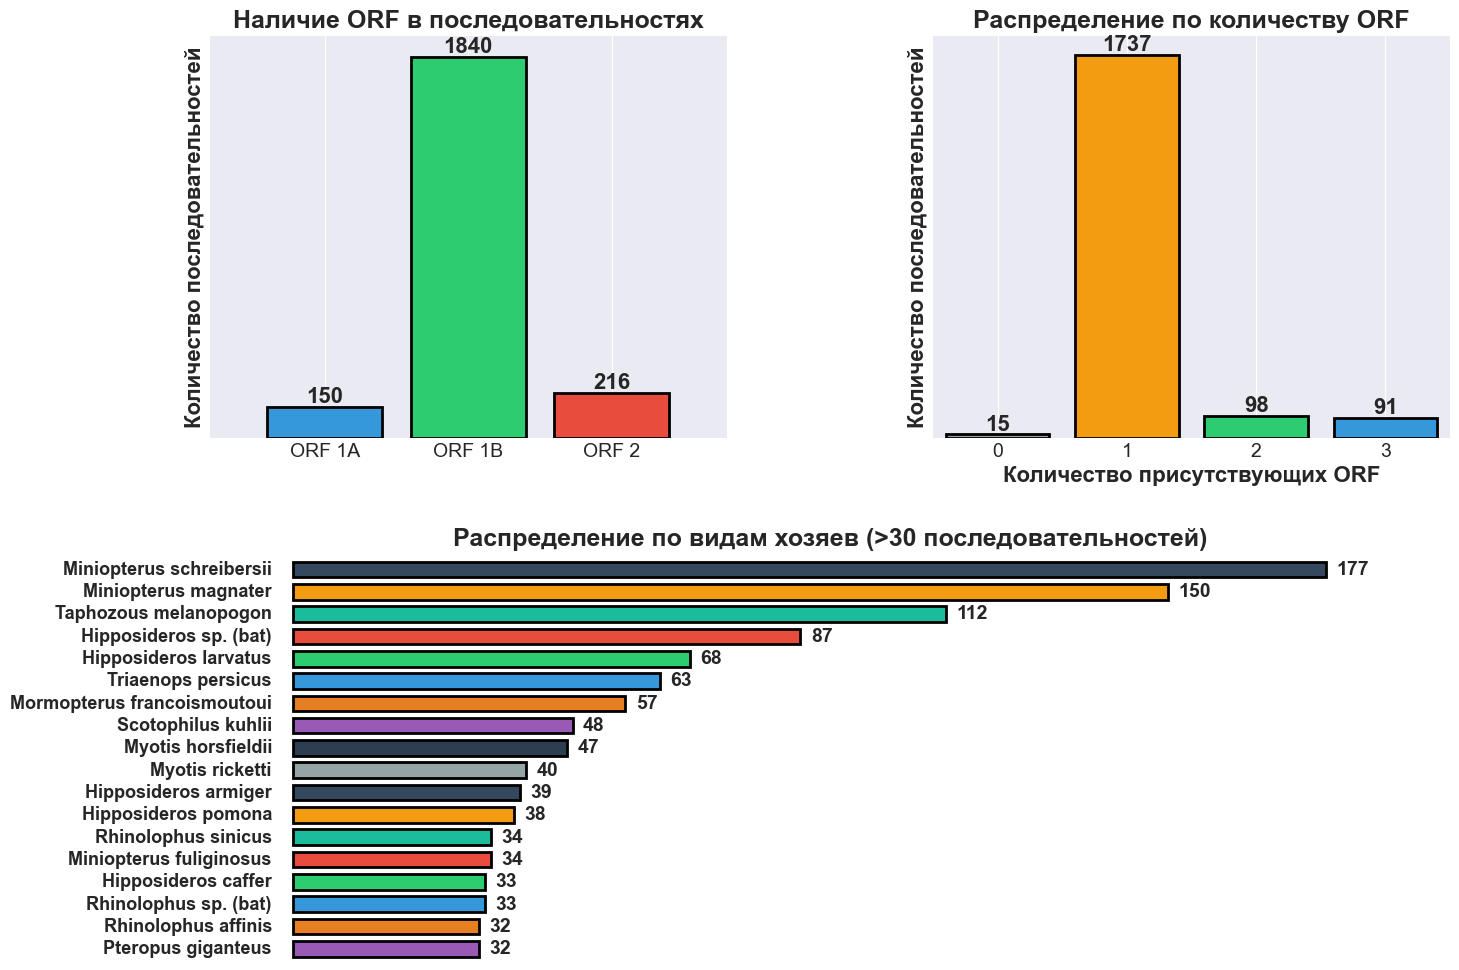


РАСПРЕДЕЛЕНИЕ ПО ХОЗЯЕВАМ (все виды)
✓ Miniopterus schreibersii: 177 (9.1%) - ВКЛЮЧЕН в диаграмму
✓ Miniopterus magnater: 150 (7.7%) - ВКЛЮЧЕН в диаграмму
✓ Taphozous melanopogon: 112 (5.8%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros sp. (bat): 87 (4.5%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros larvatus: 68 (3.5%) - ВКЛЮЧЕН в диаграмму
✓ Triaenops persicus: 63 (3.2%) - ВКЛЮЧЕН в диаграмму
✓ Mormopterus francoismoutoui: 57 (2.9%) - ВКЛЮЧЕН в диаграмму
✓ Scotophilus kuhlii: 48 (2.5%) - ВКЛЮЧЕН в диаграмму
✓ Myotis horsfieldii: 47 (2.4%) - ВКЛЮЧЕН в диаграмму
✓ Myotis ricketti: 40 (2.1%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros armiger: 39 (2.0%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros pomona: 38 (2.0%) - ВКЛЮЧЕН в диаграмму
✓ Rhinolophus sinicus: 34 (1.8%) - ВКЛЮЧЕН в диаграмму
✓ Miniopterus fuliginosus: 34 (1.8%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros caffer: 33 (1.7%) - ВКЛЮЧЕН в диаграмму
✓ Rhinolophus sp. (bat): 33 (1.7%) - ВКЛЮЧЕН в диаграмму
✓ Rhinolophus affinis: 32 (1.6%) - ВКЛЮЧЕН в диаграмму
✓ P

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"font.size": 14})

# Создаем фигуру с grid layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], hspace=0.3, wspace=0.4)

# Верхние графики
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])

# ORF 1A, 1B, 2
orf_counts = [df["has_1A"].sum(), df["has_1B"].sum(), df["has_2"].sum()]
orf_labels = ["ORF 1A", "ORF 1B", "ORF 2"]

bars = ax1.bar(
    orf_labels,
    orf_counts,
    color=["#3498db", "#2ecc71", "#e74c3c"],
    edgecolor="black",
    linewidth=2
)

ax1.set_ylabel("Количество последовательностей", fontsize=16, fontweight="bold")
ax1.set_title("Наличие ORF в последовательностях", fontsize=18, fontweight="bold")
ax1.set_ylim(0, len(df) + 1)
ax1.tick_params(axis="x", labelsize=14)
ax1.set_yticks([])
ax1.set_xlim(-0.8, 2.8)

for bar, count in zip(bars, orf_counts):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(count),
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

# Распределение по количеству ORF
orf_count_values = df["orf_count"].value_counts().sort_index()

bars = ax2.bar(
    orf_count_values.index,
    orf_count_values.values,
    color=["#95a5a6", "#f39c12", "#2ecc71", "#3498db"][:len(orf_count_values)],
    edgecolor="black",
    linewidth=2
)

ax2.set_xlabel("Количество присутствующих ORF", fontsize=16, fontweight="bold")
ax2.set_ylabel("Количество последовательностей", fontsize=16, fontweight="bold")
ax2.set_title("Распределение по количеству ORF", fontsize=18, fontweight="bold")
ax2.set_xticks(range(4))
ax2.set_yticks([])
ax2.tick_params(axis="x", labelsize=14)
ax2.set_xlim(-0.5, 3.5)

for bar, count in zip(bars, orf_count_values.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(count),
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

# Нижний график - создаем отдельный axes без осей
ax3 = plt.subplot(gs[1, :])  # Занимает всю нижнюю строку

host_counts = df["Host"].value_counts()
host_counts = host_counts[host_counts > 30].sort_values()

if not host_counts.empty:
    # Полностью отключаем оси
    ax3.axis('off')
    
    # Создаем пустой фрейм для рисования
    y_positions = range(len(host_counts))
    max_val = host_counts.max()
    
    # Рисуем горизонтальные столбцы
    bars = ax3.barh(
        y_positions,
        host_counts.values,
        color=['#9b59b6', '#e67e22', '#3498db', '#2ecc71', '#e74c3c', 
               '#1abc9c', '#f39c12', '#34495e', '#95a5a6', '#2c3e50'][:len(host_counts)],
        edgecolor="black",
        linewidth=2,
        height=0.7
    )
    
    # Добавляем названия хозяев слева
    for i, host in enumerate(host_counts.index):
        ax3.text(
            -max_val * 0.02,
            i,
            host,
            ha='right',
            va='center',
            fontsize=13,
            fontweight='bold'
        )
    
    # Добавляем значения справа
    for bar, count in zip(bars, host_counts.values):
        ax3.text(
            bar.get_width() + max_val * 0.01,
            bar.get_y() + bar.get_height() / 2,
            str(count),
            ha='left',
            va='center',
            fontsize=14,
            fontweight='bold'
        )
    
    # Устанавливаем пределы
    ax3.set_xlim(-max_val * 0.08, max_val * 1.12)
    ax3.set_ylim(-0.5, len(host_counts) - 0.5)
    
    # Добавляем заголовок
    ax3.text(
        0.5,
        1.02,
        "Распределение по видам хозяев (>30 последовательностей)",
        transform=ax3.transAxes,
        ha='center',
        va='bottom',
        fontsize=18,
        fontweight='bold'
    )

else:
    ax3.axis('off')
    ax3.text(
        0.5,
        0.5,
        "Нет хозяев с количеством > 30",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        transform=ax3.transAxes
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ПО ХОЗЯЕВАМ (все виды)")
print("=" * 60)

host_counts_all = df["Host"].value_counts()

for host, count in host_counts_all.items():
    percentage = count / len(df) * 100

    if count > 30:
        print(f"✓ {host}: {count} ({percentage:.1f}%) - ВКЛЮЧЕН в диаграмму")
    else:
        print(f" {host}: {count} ({percentage:.1f}%) - ИСКЛЮЧЕН (< 31)")

print("\n" + "=" * 60)
print("СТАТИСТИКА ПО ORF")
print("=" * 60)

print(
    f"ORF 1A присутствует в {df['has_1A'].sum()} последовательностях "
    f"({df['has_1A'].mean()*100:.1f}%)"
)

print(
    f"ORF 1B присутствует в {df['has_1B'].sum()} последовательностях "
    f"({df['has_1B'].mean()*100:.1f}%)"
)

print(
    f"ORF 2 присутствует в {df['has_2'].sum()} последовательностях "
    f"({df['has_2'].mean()*100:.1f}%)"
)

print(
    f"Полных геномов (все 3 ORF): {df['is_complete_genome'].sum()} "
    f"({df['is_complete_genome'].mean()*100:.1f}%)"
)

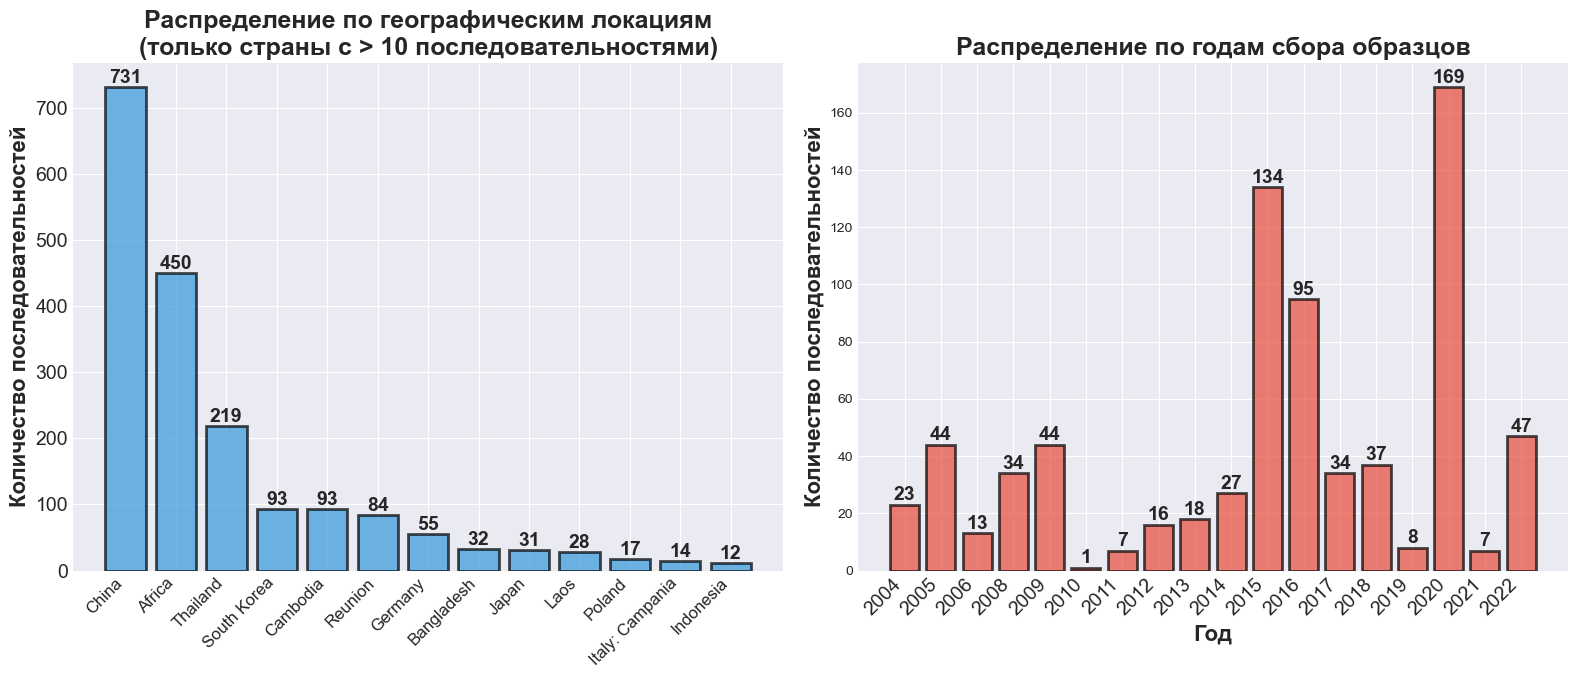


ГЕОГРАФИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ (все страны)
✓ China: 731 (37.7%) - ВКЛЮЧЕН в диаграмму
✓ Africa: 450 (23.2%) - ВКЛЮЧЕН в диаграмму
✓ Thailand: 219 (11.3%) - ВКЛЮЧЕН в диаграмму
✓ South Korea: 93 (4.8%) - ВКЛЮЧЕН в диаграмму
✓ Cambodia: 93 (4.8%) - ВКЛЮЧЕН в диаграмму
✓ Reunion: 84 (4.3%) - ВКЛЮЧЕН в диаграмму
✓ Germany: 55 (2.8%) - ВКЛЮЧЕН в диаграмму
✓ Bangladesh: 32 (1.6%) - ВКЛЮЧЕН в диаграмму
✓ Japan: 31 (1.6%) - ВКЛЮЧЕН в диаграмму
✓ Laos: 28 (1.4%) - ВКЛЮЧЕН в диаграмму
✓ Poland: 17 (0.9%) - ВКЛЮЧЕН в диаграмму
✓ Italy: Campania: 14 (0.7%) - ВКЛЮЧЕН в диаграмму
✓ Indonesia: 12 (0.6%) - ВКЛЮЧЕН в диаграмму
  Australia: Yass: 9 (0.5%) - ИСКЛЮЧЕН из диаграммы (≤ 10)
  Hungary: 8 (0.4%) - ИСКЛЮЧЕН из диаграммы (≤ 10)
  Myanmar: 8 (0.4%) - ИСКЛЮЧЕН из диаграммы (≤ 10)
  Czech Republic: 7 (0.4%) - ИСКЛЮЧЕН из диаграммы (≤ 10)
  Brazil: 6 (0.3%) - ИСКЛЮЧЕН из диаграммы (≤ 10)
  Saudi Arabia: Bisha: 6 (0.3%) - ИСКЛЮЧЕН из диаграммы (≤ 10)
  Viet Nam: 5 (0.3%) - ИСКЛЮЧЕН из диаграммы (≤ 10

In [5]:
def simplify_location(location):

    if pd.isna(location) or str(location).strip() == "":
        return location
    
    location = str(location)
    

    china_keywords = ['China', 'China:', 'Chinese', 'Guangxi', 'Jiangxi', 'Guangdong', 
                      'Yunnan', 'Sichuan', 'Hubei', 'Hunan', 'Fujian', 'Zhejiang', 
                      'Jiangsu', 'Shandong', 'Henan', 'Hebei', 'Anhui', 'Shaanxi',
                      'Shanxi', 'Liaoning', 'Jilin', 'Heilongjiang', 'Gansu', 'Qinghai',
                      'Tibet', 'Xinjiang', 'Inner Mongolia', 'Ningxia', 'Hainan',
                      'Beijing', 'Shanghai', 'Tianjin', 'Chongqing']
    

    african_countries = [
        'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
        'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad',
        'Comoros', 'Congo', "Cote d'Ivoire", 'Djibouti', 'Egypt',
        'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon',
        'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho',
        'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania',
        'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria',
        'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles',
        'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan',
        'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
    ]
    
   
    for keyword in china_keywords:
        if keyword in location:
            return "China"
    

    for country in african_countries:
        if country in location:
            return "Africa"
        if f"{country}:" in location:
            return "Africa"
    
    if 'Africa' in location:
        return "Africa"
    
    return location


df['Geo location simplified'] = df['Geo location'].apply(simplify_location)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


plt.rcParams.update({'font.size': 14})


ax1 = axes[0]
country_counts = df['Geo location simplified'].value_counts()

country_counts_filtered = country_counts[country_counts > 10]

if len(country_counts_filtered) > 0:
 
    country_counts_filtered = country_counts_filtered.sort_values(ascending=False)
    
    bars = ax1.bar(country_counts_filtered.index, country_counts_filtered.values, 
                   color='#3498db', edgecolor='black', alpha=0.7, linewidth=2)
    ax1.set_ylabel('Количество последовательностей', fontsize=16, fontweight='bold')
    ax1.set_title('Распределение по географическим локациям\n(только страны с > 10 последовательностями)', 
                  fontsize=18, fontweight='bold')
    ax1.tick_params(axis='both', labelsize=14)
    

    ax1.set_xticklabels(country_counts_filtered.index, rotation=45, ha='right', fontsize=12)
    

    for bar, count in zip(bars, country_counts_filtered.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontsize=14, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Нет стран с количеством > 10', 
             ha='center', va='center', fontsize=16, fontweight='bold', transform=ax1.transAxes)
    ax1.set_title('Распределение по географическим локациям', fontsize=18, fontweight='bold')


ax2 = axes[1]
year_counts = df['Collection date'].value_counts().sort_index()

year_counts = year_counts[pd.to_numeric(year_counts.index, errors='coerce').notnull()]

if len(year_counts) > 0:
    bars = ax2.bar(year_counts.index.astype(str), year_counts.values, 
                   color='#e74c3c', edgecolor='black', alpha=0.7, linewidth=2)
    ax2.set_xlabel('Год', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Количество последовательностей', fontsize=16, fontweight='bold')
    ax2.set_title('Распределение по годам сбора образцов', fontsize=18, fontweight='bold')
    ax2.tick_params(axis='both', labelsize=10)

    ax2.set_xticklabels(year_counts.index, rotation=45, ha='right', fontsize=14)
    

    for bar, count in zip(bars, year_counts.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Нет данных по годам', 
             ha='center', va='center', fontsize=12, fontweight='bold', transform=ax2.transAxes)
    ax2.set_title('Распределение по годам сбора образцов', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("ГЕОГРАФИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ (все страны)")
print("="*60)
country_counts_all = df['Geo location simplified'].value_counts()
for country, count in country_counts_all.items():
    percentage = (count / len(df)) * 100
    if count > 10:
        print(f"✓ {country}: {count} ({percentage:.1f}%) - ВКЛЮЧЕН в диаграмму")
    else:
        print(f"  {country}: {count} ({percentage:.1f}%) - ИСКЛЮЧЕН из диаграммы (≤ 10)")

print("\n" + "="*60)
print("ПРИМЕРЫ ОБЪЕДИНЕНИЯ ЛОКАЦИЙ")
print("="*60)

sample_locations = df['Geo location'].dropna().unique()[:20]
for loc in sample_locations:
    simplified = simplify_location(loc)
    if loc != simplified:
        print(f"  {loc} -> {simplified}")

print("\n" + "="*60)
print("СТАТИСТИКА ПО РЕГИОНАМ")
print("="*60)

china_count = len(df[df['Geo location simplified'] == 'China'])
africa_count = len(df[df['Geo location simplified'] == 'Africa'])
other_count = len(df[~df['Geo location simplified'].isin(['China', 'Africa'])])

print(f"  China: {china_count} ({china_count/len(df)*100:.1f}%)")
print(f"  Africa: {africa_count} ({africa_count/len(df)*100:.1f}%)")
print(f"  Other: {other_count} ({other_count/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("ВРЕМЕННОЕ РАСПРЕДЕЛЕНИЕ")
print("="*60)
years_all = df['Collection date'].unique()
years_all = [y for y in years_all if str(y).isdigit()]
for year in sorted(years_all):
    count = len(df[df['Collection date'] == year])
    percentage = (count / len(df)) * 100
    print(f"{year}: {count} ({percentage:.1f}%)")

if len(years_all) > 0:
    print("\nСтатистика по годам:")
    print(f"  Самый ранний год: {min(years_all)}")
    print(f"  Самый поздний год: {max(years_all)}")
    print(f"  Количество уникальных годов: {len(set(years_all))}")
    print(f"  Среднее количество последовательностей в год: {len(df) / len(set(years_all)):.1f}")

In [6]:
# Cell 9: Summary table and additional statistics
print("="*80)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*80)

print("\n1. BASIC SEQUENCE INFORMATION")
print("-"*40)
print(f"Total number of sequences: {len(df)}")
print(f"Total unique hosts: {df['Host'].nunique()}")
print(f"Total countries: {df['Country'].nunique()}")

print("\n2. ORF PRESENCE")
print("-"*40)
orf_presence = pd.DataFrame({
    'ORF': ['1A', '1B', '2'],
    'Present in': [df['has_1A'].sum(), df['has_1B'].sum(), df['has_2'].sum()],
    'Percentage': [f"{(df['has_1A'].sum()/len(df))*100:.1f}%",
                   f"{(df['has_1B'].sum()/len(df))*100:.1f}%",
                   f"{(df['has_2'].sum()/len(df))*100:.1f}%"]
})
print(orf_presence.to_string(index=False))

print("\n3. GENOME COMPLETENESS")
print("-"*40)
complete_df = df[df['is_complete_genome']]
print(f"Complete genomes (all 3 ORFs): {len(complete_df)} ({len(complete_df)/len(df)*100:.1f}%)")
print(f"Partial genomes: {len(df)-len(complete_df)} ({(len(df)-len(complete_df))/len(df)*100:.1f}%)")

print("\n4. ORF LENGTH STATISTICS")
print("-"*40)
for orf in ['1A', '1B', '2']:
    lengths = df[df[f'{orf}_length'] > 0][f'{orf}_length']
    if len(lengths) > 0:
        print(f"\nORF {orf}:")
        print(f"  n={len(lengths)}")
        print(f"  Mean: {lengths.mean():.0f} ± {lengths.std():.0f} nt")
        print(f"  Range: {lengths.min()} - {lengths.max()} nt")
        print(f"  Median: {lengths.median():.0f} nt")

print("\n5. HOST DISTRIBUTION")
print("-"*40)
host_dist = df['Host'].value_counts()
for host, count in host_dist.items():
    print(f"{host}: {count} ({count/len(df)*100:.1f}%)")

print("\n6. YEAR DISTRIBUTION")
print("-"*40)
year_dist = df['Collection date'].value_counts().sort_index()
for year, count in year_dist.items():
    if str(year).isdigit():
        print(f"{year}: {count} ({count/len(df)*100:.1f}%)")

COMPREHENSIVE SUMMARY STATISTICS

1. BASIC SEQUENCE INFORMATION
----------------------------------------
Total number of sequences: 1941
Total unique hosts: 200
Total countries: 0

2. ORF PRESENCE
----------------------------------------
ORF  Present in Percentage
 1A         150       7.7%
 1B        1840      94.8%
  2         216      11.1%

3. GENOME COMPLETENESS
----------------------------------------
Complete genomes (all 3 ORFs): 91 (4.7%)
Partial genomes: 1850 (95.3%)

4. ORF LENGTH STATISTICS
----------------------------------------

ORF 1A:
  n=150
  Mean: 1771 ± 918 nt
  Range: 76 - 5527 nt
  Median: 1850 nt

ORF 1B:
  n=1840
  Mean: 503 ± 374 nt
  Range: 148 - 4225 nt
  Median: 382 nt

ORF 2:
  n=216
  Mean: 1620 ± 785 nt
  Range: 17 - 2605 nt
  Median: 2052 nt

5. HOST DISTRIBUTION
----------------------------------------
Miniopterus schreibersii: 177 (9.1%)
Miniopterus magnater: 150 (7.7%)
Taphozous melanopogon: 112 (5.8%)
Hipposideros sp. (bat): 87 (4.5%)
Hipposideros l

In [7]:
import numpy as np

frames = ["1A", "1B", "2"]

for frame in frames:
    df[frame] = df[frame].replace("NA-NA", np.nan)

    coords = df[frame].str.split("-", expand=True)

    start = pd.to_numeric(coords[0], errors="coerce")
    end = pd.to_numeric(coords[1], errors="coerce")

    df[f"{frame}_length"] = end - start + 1
df

,Unnamed: 0,ID,Version,GenBank title,Release date,Organism name,Virus Lineage,Species,Family,Length,...,class,1A_length,1B_length,2_length,has_1A,has_1B,has_2,orf_count,is_complete_genome,Geo location simplified
0,51,OR951098,OR951098.1,MAG: Bat astrovirus isolate JX2021_368_226027 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,3758.0,...,Mammalia,760.0,1582.0,754.0,True,True,True,3,True,China
1,52,OR951097,OR951097.1,MAG: Bat astrovirus isolate JX2021_367_194485 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,6021.0,...,Mammalia,1951.0,1579.0,2197.0,True,True,True,3,True,China
2,53,OR951096,OR951096.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1608.0,...,Mammalia,NaN,1368.0,NaN,False,True,False,1,False,China
3,54,OR951095,OR951095.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1381.0,...,Mammalia,NaN,1372.0,NaN,False,True,False,1,False,China
4,55,OR951094,OR951094.1,MAG: Bat astrovirus isolate FJ2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1850.0,...,Mammalia,NaN,1234.0,NaN,False,True,False,1,False,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,15028,JQ814860,JQ814860.1,Miniopterus schreibersii astrovirus 5 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 5,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,Mammalia,NaN,388.0,NaN,False,True,False,1,False,China
1937,15029,JQ814859,JQ814859.1,Miniopterus schreibersii astrovirus 4 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 4,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,Mammalia,NaN,388.0,NaN,False,True,False,1,False,China
1938,15030,JQ814858,JQ814858.1,Miniopterus schreibersii astrovirus 3 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 3,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,Mammalia,NaN,388.0,NaN,False,True,False,1,False,China
1939,15031,JQ814857,JQ814857.1,Miniopterus schreibersii astrovirus 2 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 2,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,Mammalia,NaN,388.0,NaN,False,True,False,1,False,China


In [8]:
df[frames].isna().all(axis=1).sum()

np.int64(15)

In [ ]:
mask_all_nan = df[frames].isna().all(axis=1)
rows_all_nan = mask_all_nan.sum()

In [ ]:
mask_all_nan = df[frames].isna().all(axis=1)
rows_with_all_nan = df[mask_all_nan]

In [ ]:
print(rows_with_all_nan)

      Unnamed: 0        ID     Version  \
193         1399  PQ038334  PQ038334.1   
194         1400  PQ038333  PQ038333.1   
195         1401  PQ038332  PQ038332.1   
322         2172  OR613370  OR613370.1   
344         2194  OR613348  OR613348.1   
394         2244  OR613296  OR613296.1   
398         2248  OR613292  OR613292.1   
652         2854  OQ709193  OQ709193.1   
653         2855  OQ709192  OQ709192.1   
654         2856  OQ709191  OQ709191.1   
655         2857  OQ709190  OQ709190.1   
656         2858  OQ709189  OQ709189.1   
657         2859  OQ709188  OQ709188.1   
1790       12917  KT003292  KT003292.1   
1909       14103  KC599256  KC599256.1   

                                          GenBank title Release date  \
193   UNVERIFIED: Bat astrovirus isolate MIZ141 RNA-...  31-JUL-2024   
194   UNVERIFIED: Bat astrovirus isolate KEL299B RNA...  31-JUL-2024   
195   UNVERIFIED: Bat astrovirus isolate KEL200 RNA-...  31-JUL-2024   
322   UNVERIFIED: Bat astrovirus isolat

In [ ]:
df[frames].notna().sum()

1A     150
1B    1840
2      216
dtype: int64

In [ ]:
df[frames].isna().sum()

1A    1791
1B     101
2     1725
dtype: int64

In [ ]:
df[[f"{f}_length" for f in frames]].describe()

,1A_length,1B_length,2_length
count,150.000000,1840.000000,216.000000
mean,1770.746667,503.382609,1620.472222
std,917.871957,374.457076,784.614448
min,76.000000,148.000000,17.000000
25%,971.500000,366.000000,730.000000
50%,1850.000000,382.000000,2051.500000
75%,2597.500000,397.000000,2223.250000
max,5527.000000,4225.000000,2605.000000


In [ ]:
length_cols = ["1A_length", "1B_length", "2_length"]

summary = df[length_cols].describe()
print(summary)

         1A_length    1B_length     2_length
count   150.000000  1840.000000   216.000000
mean   1770.746667   503.382609  1620.472222
std     917.871957   374.457076   784.614448
min      76.000000   148.000000    17.000000
25%     971.500000   366.000000   730.000000
50%    1850.000000   382.000000  2051.500000
75%    2597.500000   397.000000  2223.250000
max    5527.000000  4225.000000  2605.000000


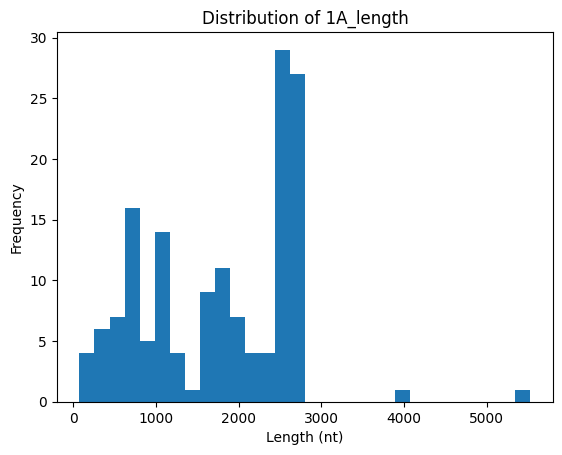

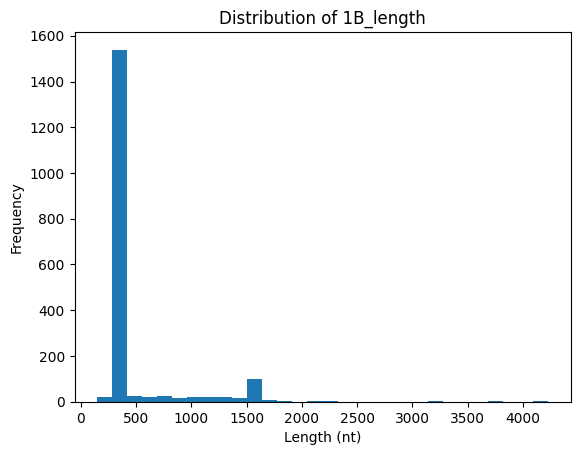

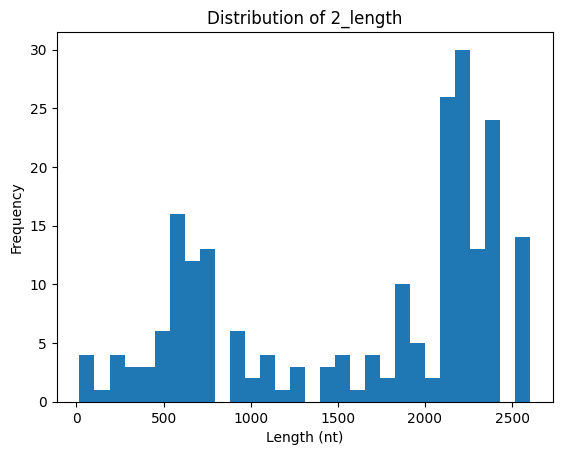

In [ ]:
import matplotlib.pyplot as plt

for col in length_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel("Length (nt)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()